In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import math
from matplotlib.widgets import Slider, Button
import pandas as pd
from scipy.interpolate import make_interp_spline

# Part 1: Self-diffusion (tracer diffusion) in a bar

## Part 1 (i): Derivation and analytical solutions

### Infinite bar: erf solution

Fick's second law with constant $D$:

$$\frac{\partial C}{\partial t}=D\frac{\partial^2C}{\partial x^2}$$

**IC:** $C(x,0)=C_1$ for $x<0$, $C_2$ for $x>0$ &nbsp;&nbsp; **BC:** $C(-\infty,t)=C_1$, $C(\infty,t)=C_2$

1. **Similarity variable.** With $\eta = x/(2\sqrt{Dt})$ the PDE becomes an ODE: $C'' + 2\eta\,C' = 0$.
2. **Integration.** $C' = A\,e^{-\eta^2}$, which gives $C = B + A'\,\mathrm{erf}(\eta)$.
3. **Constants.** $\mathrm{erf}(\pm\infty)=\pm1$ and the boundary conditions give $B=\tfrac{C_1+C_2}{2}$ and $A'=-\tfrac{C_1-C_2}{2}$.

$$C(x,t) = \frac{C_1 + C_2}{2} - \frac{C_1 - C_2}{2}\,\mathrm{erf}\!\left(\frac{x}{2\sqrt{Dt}}\right), \qquad
\frac{\partial C}{\partial x} = -\frac{C_1 - C_2}{2\sqrt{\pi D t}}\exp\!\left(-\frac{x^2}{4Dt}\right)$$

Starting from Fick's second law,

$$
\frac{\partial C}{\partial t}
=D\frac{\partial^2C}{\partial x^2},
$$

assume \(C(x,t)=X(x)T(t)\). Separation of variables gives

$$
\frac{T'}{DT}=\frac{X''}{X}=-k^2.
$$

Thus,

$$
T=e^{-Dk^2t},
\qquad
X=A\cos kx+B\sin kx.
$$

### Finite interval

On \(-l\le x\le l\), impose

$$
X'(-l)=X'(l)=0.
$$

The eigenfunctions include the odd sine family

$$
k_n=\frac{(n+\frac12)\pi}{l},
\qquad
X_n=\sin(k_nx).
$$

For the step initial condition

$$
C(x,0)=
\begin{cases}
C_1,&x<0,\\
C_2,&x>0,
\end{cases}
$$

define

$$
\bar C=\frac{C_1+C_2}{2},
\qquad
\Delta C=C_2-C_1.
$$

Since \(C(x,0)-\bar C\) is odd, only the sine modes occur. Their coefficients are

$$
b_n=\frac{\Delta C}{lk_n}.
$$

Hence

$$
C_l(x,t)=\bar C+
\frac{\Delta C}{l}
\sum_{n=0}^\infty
\frac{\sin(k_nx)}{k_n}e^{-Dk_n^2t}.
$$

### Infinite-domain limit

Let

$$
\Delta k=\frac{\pi}{l},
\qquad
k_n=(n+\tfrac12)\Delta k,
\qquad
\frac1l=\frac{\Delta k}{\pi}.
$$

As \(l\to\infty\), the sum becomes an integral:

$$
C(x,t)=\bar C+
\frac{\Delta C}{\pi}
\int_0^\infty
\frac{\sin(kx)}{k}e^{-Dk^2t}\,dk.
$$

Define

$$
I=\int_0^\infty\frac{\sin(kx)}{k}e^{-Dk^2t}\,dk.
$$

Differentiating with respect to \(x\),

$$
\frac{\partial I}{\partial x}
=\int_0^\infty e^{-Dk^2t}\cos(kx)\,dk
=
\frac{\sqrt{\pi}}{2\sqrt{Dt}}
e^{-x^2/(4Dt)}.
$$

Integrating with \(I(0,t)=0\),

$$
I=\frac{\pi}{2}
\operatorname{erf}\left(\frac{x}{2\sqrt{Dt}}\right).
$$

Therefore,

$$
\boxed{
C(x,t)=
\frac{C_1+C_2}{2}
+
\frac{C_2-C_1}{2}
\operatorname{erf}
\left(\frac{x}{2\sqrt{Dt}}\right)
}
$$

which is the error-function solution for diffusion across an initially sharp concentration interface.


**The analytical solution (erf), briefly explained**

**The problem.** A bar of pure Cu (or Ni) where half of the atoms are labelled as tracer:
$C = 0$ for $x < 0$, $C = 1$ for $x > 0$. After 30 h at 1000 °C, self-diffusion has smeared out the
sharp boundary in the middle.

**The solution of Fick's 2nd law with these conditions:**

$$C(x,t) = \frac{C_1 + C_2}{2} - \frac{C_1 - C_2}{2}\,\mathrm{erf}\!\left(\frac{x}{2\sqrt{Dt}}\right)$$

- The first term is the mean value — where the profile ends up eventually.
- $\mathrm{erf}$ is an S-curve from $-1$ to $+1$ and gives the smooth transition.
- Everything depends on $x/(2\sqrt{Dt})$: **$\sqrt{Dt}$ is the length scale** for how far the
  diffusion has reached. A profile twice as wide requires four times as long.

**The gradient** is the derivative, a Gaussian bell curve with peak
$|C_1 - C_2|/(2\sqrt{\pi D t})$ at $x = 0$. The peak decreases with time, so the driving force for
further diffusion ($J = -D\,\partial C/\partial x$) decreases.

In [2]:
# Diffusion coefficient function, D(T)
def Diff_coeff(T, D0, Q):
    return D0*np.exp(-Q*1000/(R*T))

In [3]:
# Concentration profile function, C(x,t)
def Concentration_profile(x, t, D, C1, C2):
    return (C1+C2)/2 - (C1-C2)/2 * math.erf(x/(2*np.sqrt(D*t)))

In [4]:
# Concetraion gradients
def Concentration_gradient(x, t, D, C1, C2):
    return -(C1-C2)/(2*np.sqrt(np.pi*D*t)) * np.exp(-x**2/(4*D*t))

### Example: finite bar with fixed ends

Fick's second law on $[-L, L]$ with $L = 1$ mm:

$$\frac{\partial C}{\partial t}=D\frac{\partial^2C}{\partial x^2}$$

**BC:** $C(-L,t)=0$, $C(L,t)=1$ &nbsp;&nbsp; **IC:** $C(x,0)=0$ for $x<0$, $1$ for $x>0$

#### Procedure

1. **Steady state.** $C''=0$ gives $C_{ss}(x)=\tfrac12+\tfrac{x}{2L}$.
2. **Split off** with $u=C-C_{ss}$, so that $u(\pm L,t)=0$. Then $u_0(x)=\tfrac12\operatorname{sgn}(x)-\tfrac{x}{2L}$, which is odd about $x=0$.
3. **Separation of variables** on $u$: $T'=-\lambda DT$ and $X''=-\lambda X$. The boundary conditions give $k=m\pi/L$; the cosine modes vanish because $u_0$ is odd.
4. **Orthogonality** gives $a_m=\tfrac1L\int_{-L}^{L}u_0\sin\tfrac{m\pi x}{L}dx=+\tfrac{1}{m\pi}$.

#### Result

$$C(x,t)=\frac{1}{2}+\frac{x}{2L}+\frac{1}{\pi}\sum_{m=1}^{\infty}\frac{1}{m}\sin\!\left(\frac{m\pi x}{L}\right)\exp\!\left(-\frac{m^2\pi^2Dt}{L^2}\right)$$

The first term is the steady state (a straight ramp — not $\tfrac12$ everywhere, since the ends are held fixed), the second term is the deviation that dies out. Mode $m$ has lifetime $\tau_m = L^2/(m^2\pi^2 D)$.

In [5]:
# Analytical solution, finite bar with fixed ends

def analytical_solution(x, t, T, M=500):
    # Steady state: straight ramp from C=0 at x=-L to C=1 at x=+L
    D = Diff_coeff(T, D0_Cu, Q_Cu)  # ~1.9e-13 m^2/s
    C = 0.5 + x / (2 * L)
    # Adding the Fourier modes that die out with time
    for m in range(1, M + 1):
        # each mode: amplitude +1/(m*pi), shape factor sin(m*pi*x/L), damping exp(-m^2*pi^2*D*t/L^2)
        C += (1 / (m * np.pi)) * np.sin(m * np.pi * x / L) * np.exp(-(m * np.pi / L) ** 2 * D * t)
    return C

## Part 1 (ii): Isotherm annealing: Analytical solution

Result: plot of concentration vs distance and contration gradient vs distance 
Self diffusion of Ni* and Cu* tracer atoms in bars of Ni and Cu, respectively. 

In [6]:
# Problem parameters
T=1000+273.15 # K
t_tot=30*3600 # s
R=8.314 # J/mol*K
x = np.linspace(-1e-3, 1e-3, 101) # m, i.e. from -1 mm to 1 mm

# Material parameters (experimental values from table 2.2 in Porter et al. Phase Transformations in Metals and Alloys)
D0_Cu=31e-6 # m^2/s
D0_Ni=190e-6 # m^2/s
Q_Cu=200.3 # kJ/mol
Q_Ni=279.7 # kJ/mol

D_Cu=Diff_coeff(T, D0_Cu, Q_Cu)
D_Ni=Diff_coeff(T, D0_Ni, Q_Ni)

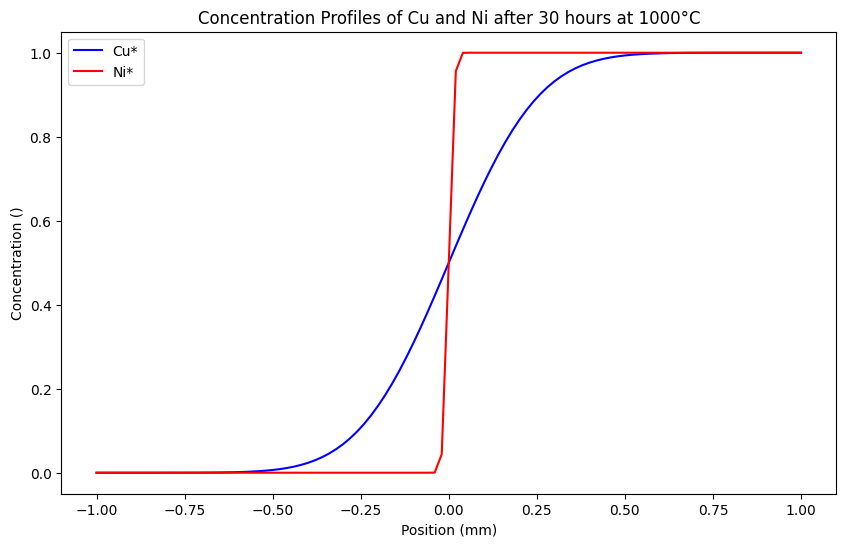

In [7]:
# Calculating concentration profiles for Cu and Ni, with inital condtion: 
# C(x,1)= 1 for x>0 and C(x,1)= 0 for x<0
C_Cu = []  
C_Ni = []

for xi in x:
    C_Cu.append(Concentration_profile(xi, t_tot, D_Cu, 0, 1))
    C_Ni.append(Concentration_profile(xi, t_tot, D_Ni, 0, 1))

# Plotting the concentration profiles
plt.figure(figsize=(10, 6))
plt.plot(x*1e3, C_Cu, label='Cu*', color='blue')
plt.plot(x*1e3, C_Ni, label='Ni*', color='red')
plt.title('Concentration Profiles of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)')     
plt.ylabel('Concentration ()')
plt.legend()
plt.legend()

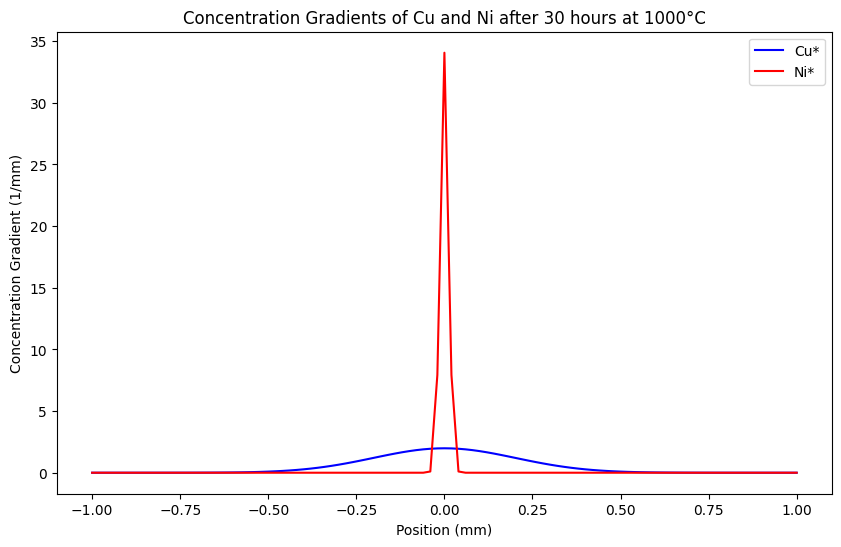

In [8]:
Cons_Cu_grad = []
Cons_Ni_grad = []

for xi in x:
    Cons_Cu_grad.append(Concentration_gradient(xi, t_tot, D_Cu, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm
    Cons_Ni_grad.append(Concentration_gradient(xi, t_tot, D_Ni, 0, 1)*1e-3) # multiplied by 1e-3 to convert to mm

plt.figure(figsize=(10, 6))
plt.plot(x*1e3, Cons_Cu_grad, label='Cu*', color='blue')
plt.plot(x*1e3, Cons_Ni_grad, label='Ni*', color='red')
plt.title('Concentration Gradients of Cu and Ni after 30 hours at 1000°C')
plt.xlabel('Position (mm)') 
plt.ylabel('Concentration Gradient (1/mm)')
plt.legend()        

### Finite bar with fixed ends

[]

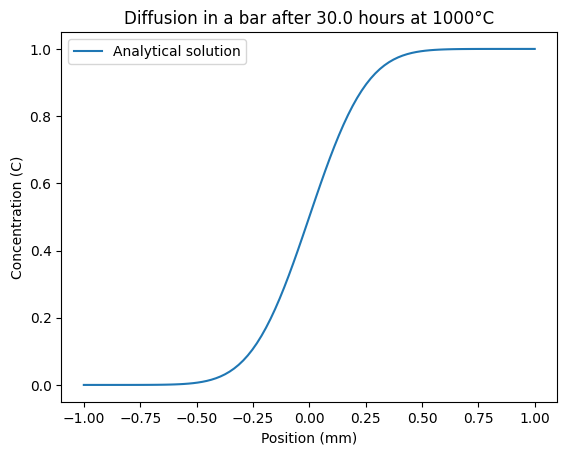

In [9]:
# ------------------- Parameters -------------------
L = 1e-3           # m, distance from the centre to the end of the bar
time = 30 * 3600   # s, 30 hours
T = 1000 + 273.15  # K, isothermal annealing at 1000 C
positions = np.linspace(-L, L, 100)  # 100 points from -L to L
# -------------------------------------------------

analytical_sol = analytical_solution(positions, time, T)
# multiplied by 1e3 to get mm on the x-axis (computed internally in metres since D is in m^2/s)
plt.plot(positions * 1e3, analytical_sol, label='Analytical solution')
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Diffusion in a bar after {time/3600} hours at 1000°C')
plt.legend()
plt.plot()

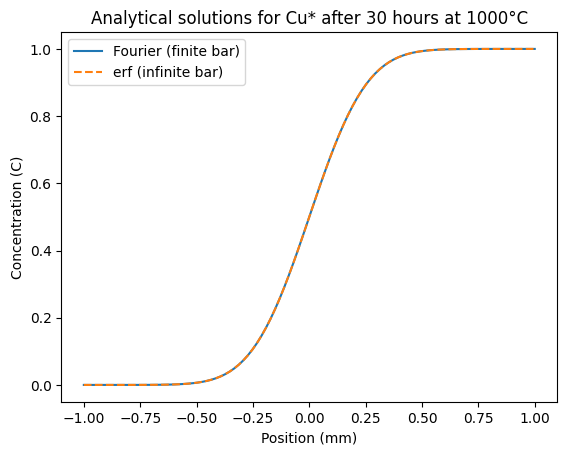

In [10]:
# Both analytical solutions in the same plot (Cu*, 30 h at 1000 °C). erf with C1=0, C2=1 for the same orientation
plt.figure()
plt.plot(positions * 1e3, analytical_sol, label='Fourier (finite bar)')
plt.plot(positions * 1e3, [Concentration_profile(xi, time, D_Cu, 0, 1) for xi in positions], '--', label='erf (infinite bar)')
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title('Analytical solutions for Cu* after 30 hours at 1000°C')
plt.legend()
plt.show()

## Part 1 (iii): Numerical solution with the finite difference method (FDM)

The bar is divided into grid points $x_j = j\,\Delta x$ and time into steps $t^n = n\,\Delta t$, and the derivatives in Fick's 2nd law are replaced by differences:

$$\frac{C_j^{n+1}-C_j^n}{\Delta t} = D\,\frac{C_{j+1}-2C_j+C_{j-1}}{(\Delta x)^2}$$

- **Explicit:** the right-hand side is evaluated at time $n$, so $C_j^{n+1}$ is computed directly. Stable only for $D\Delta t/(\Delta x)^2 \le \tfrac12$.
- **Implicit:** the right-hand side is evaluated at time $n+1$, which gives a tridiagonal system of equations per time step. Stable for all $\Delta t$.

### Numerical solution by finite difference method with explisit timesteps

Numerical solution to substitutional self-diffusion of tracer atoms in bar. I.e. Cu* in Cu and Ni* in Ni (diffusion couple) 

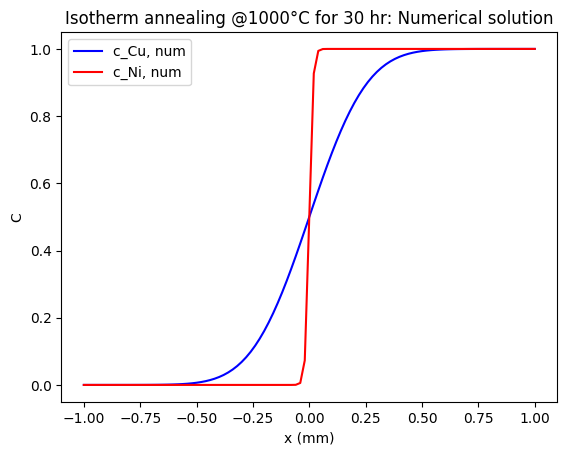

In [11]:
dx_mm = 0.02              # spatial step in mm
dx = dx_mm * 1e-3         # spatial step in m
dt=600 # timestep, seconds (should be within bounds of stability, i.e. dt < dx^2/(2*D))

N = int(t_tot/ dt)   # number of time steps
J = int(2/dx_mm)       # number of spatial steps

# Grid 
x = np.linspace(-1, 1, J+1) # mm
c = np.zeros(J+1)

# Initial condition 
# c(x,0) = 1 for x>0, 0 for x<0  
c[x > 0] = 1
c[x < 0] = 0
c[x == 0] = 0.5 # Condition at midpoint

def num_sol(D, c0, dt, dx, N, J):
    c = c0.copy()
    for n in range(N):
        c_new = c.copy()
        for j in range(1, J):
            c_new[j] = D*dt/dx**2 * (c[j+1] - 2*c[j] + c[j-1]) + c[j]
        c_new[0] = c0[0]   # Dirichlet: hold at initial boundary values
        c_new[J] = c0[J]
        c = c_new
    return c

c_Cu = num_sol(D_Cu, c, dt, dx, N, J)
c_Ni = num_sol(D_Ni, c, dt, dx, N, J)

plt.plot(x, c_Cu, label='c_Cu, num', color='blue')  
plt.plot(x, c_Ni, label='c_Ni, num', color='red')
plt.xlabel('x (mm)')
plt.ylabel('C')
plt.title('Isotherm annealing @1000°C for 30 hr: Numerical solution')
plt.legend()
plt.show()

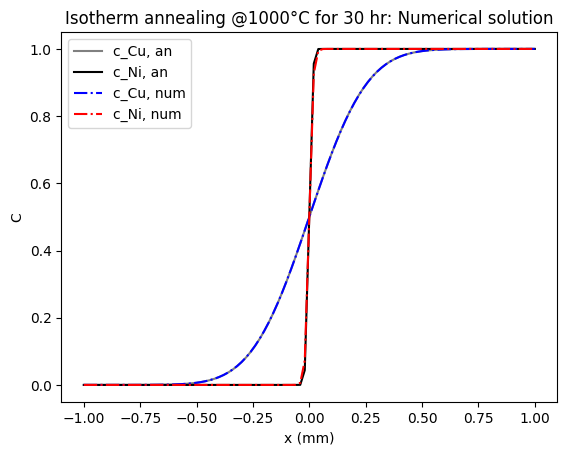

In [12]:
# Plot with analytical solution for comparison 
plt.plot(x, C_Cu, label='c_Cu, an',color='grey')
plt.plot(x, C_Ni, label='c_Ni, an', color='black')
plt.plot(x, c_Cu, label='c_Cu, num',linestyle='dashdot', color='blue')  
plt.plot(x, c_Ni, label='c_Ni, num',linestyle='dashdot', color='red')
plt.xlabel('x (mm)')
plt.ylabel('C')
plt.title('Isotherm annealing @1000°C for 30 hr: Numerical solution')
plt.legend()
plt.show()

### Explicit FDM with fluxes between the nodes (also accepts a vector of $D$)

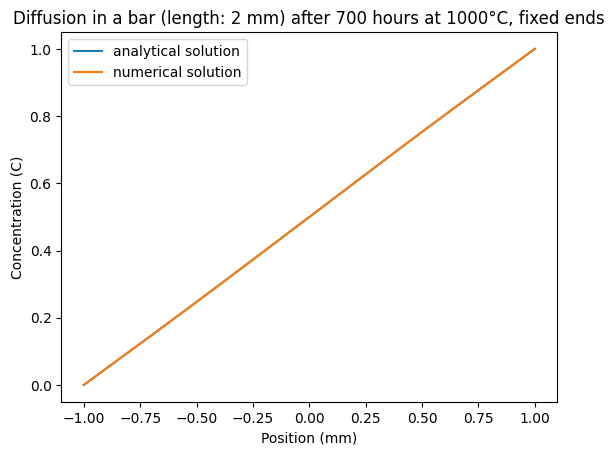

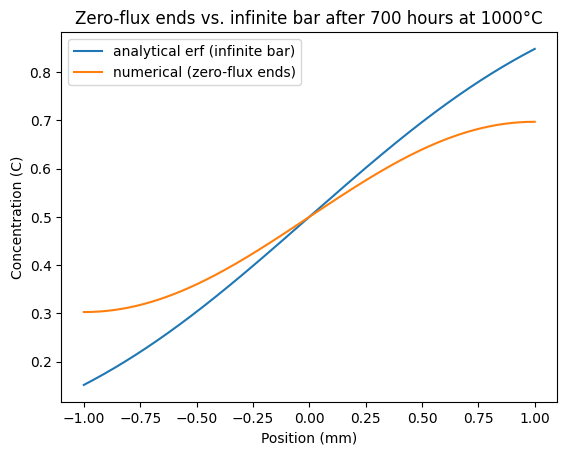

In [13]:
# Solution with the finite difference method, constant diffusion coefficient D and temperature T

#------------------------------------------------------------------------
#---------------------- Vurderer å fjerne hele greia --------------------
#------------------------------------------------------------------------

def central_diff(C, D, dx, D_list = None):
    if D_list is not None:
        # D midel between gridpoints:  D_{j+1/2} = (D_j + D_{j+1}) / 2
        D_face = 0.5 * (D_list[:-1] + D_list[1:])
        # Fick's 1st law on the faces:  J_{j+1/2} = -D_{j+1/2} * (C_{j+1} - C_j) / dx
        J = -D_face * (C[1:] - C[:-1]) / dx        # C[1:] = C_{j+1},  C[:-1] = C_j
    else:
        J = -D * (C[1:] - C[:-1]) / dx

    # dC_j/dt = -(J_{j+1/2} - J_{j-1/2}) / dx
    dCdt = np.zeros_like(C)
    dCdt[1:-1] = -(J[1:] - J[:-1]) / dx           # J[1:] = J_{j+1/2},  J[:-1] = J_{j-1/2}
    return dCdt, J

def iteration_1(C, D, dx, t_end, alpha=0.4):
    # dt is computed from stability: alpha = D*dt/dx^2 <= 0.5
    dt = alpha * dx**2 / D
    t = 0
    C = np.array(C, dtype=float)
    history = [C.copy()]
    while t < t_end:
        dcdt, J = central_diff(C, D, dx)
        C = C + dt * dcdt
        history.append(C.copy())
        t += dt
    return history

def iteration_2(C, D, dx, t_end, alpha=0.4):
    # dt is computed from stability: alpha = D*dt/dx^2 <= 0.5
    dt = alpha * dx**2 / D
    t = 0
    C = np.array(C, dtype=float)
    history = [C.copy()]
    while t < t_end:
        dcdt, J = central_diff(C, D, dx)
        C = C + dt * dcdt
        C[0]=C[1]; C[-1]=C[-2] # Different boundary condition, not fixed ends
        history.append(C.copy())
        t += dt
    return history

#----------- Parameters -----------------
grid_points = 300 # number of points
t_end = 3600 * 700 # s (700 hours)
T = 1000 + 273 # K
L = 1e-3 # m, distance from the centre to the ends of the bar

# C_grid
concentrations = np.zeros(grid_points)
concentrations[grid_points//2:] = 1.0

# positions
dx = 2*L / (grid_points - 1)
positions = np.linspace(-L,L,grid_points)
positions_fine = np.linspace(-L,L,1000)
D = Diff_coeff(T, D0_Cu, Q_Cu)

# ------------- Fixed concentration at the ends (C=0 at x=-L, C=1 at x=L) ----------------
analy = analytical_solution(positions_fine, t_end, T)
num = iteration_1(concentrations,D,dx,t_end,alpha=0.4)
plt.plot(positions_fine * 1e3,analy,label="analytical solution")
plt.plot(positions * 1e3,num[-1],label="numerical solution")   # num[-1] = last time step
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Diffusion in a bar (length: {2*L*1e3:.0f} mm) after {t_end/3600:.0f} hours at {T-273}°C, fixed ends')
plt.legend()
plt.plot()

# -------------- Fixed amount in the whole bar -------------------------------
# C1=0, C2=1 gives the same orientation as here: C=0 for x<0, C=1 for x>0
analy_erf = [Concentration_profile(xi, t_end, D, 0, 1) for xi in positions_fine]
num_2 = iteration_2(concentrations, D, dx, t_end, alpha=0.4)   # zero flux: C[0]=C[1], C[-1]=C[-2]

plt.figure()
plt.plot(positions_fine * 1e3, analy_erf, label="analytical erf (infinite bar)")
plt.plot(positions * 1e3, num_2[-1], label="numerical (zero-flux ends)")
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Zero-flux ends vs. infinite bar after {t_end/3600:.0f} hours at {T-273}°C')
plt.legend()
plt.show()

### Implicit FDM scheme

In [14]:
#Defining variables to use later
x_min = -1
x_max = 1
x_steps = 120
t_max = 312 # Hours
t_max0 = t_max
t_max = t_max * 3600 # Convert to seconds
t_steps = 10

R = 8.314e-3      # kJ/(mol*K)
T = 1273          # K (1000 °C)

D0_Cu, Q_Cu = 31, 200.3     # mm^2/s, kJ/mol
D0_Ni, Q_Ni = 190, 279.7    # mm^2/s, kJ/mol

D0_Cu = D0_Cu * np.exp(-Q_Cu / (R * T))   # Cu*  in Cu
D0_Ni = D0_Ni * np.exp(-Q_Ni / (R * T)) # Ni*  in Ni
D = D0_Cu
# D = 10**-5


In [15]:
def setup(x_min=x_min, x_max=x_max, x_steps=x_steps, t_max=t_max, t_steps=t_steps, D=D):
    x = np.linspace(x_min, x_max, x_steps)
    C_matrix = np.zeros((t_steps, x_steps))
    C_matrix[0, :] = np.heaviside(x, 0.5)   # Using heaviside function to set the first row to 1 for x >= 0 and 0 for x < 0
    dx = (x_max - x_min) / (x_steps - 1)
    dt = t_max / (t_steps - 1)
    r = np.full((x_steps,), D * dt / dx**2)  # r is a vector of length x_steps with the same value D*dt/dx^2
    return C_matrix, dx, dt, r, x

C_matrix, dx, dt, r, x = setup()

In the cell above, a grid of 0s is defined, with the initial condition, C = 1 for positive x and 0 for negative x, is put into the grid. Also, dx, dt and r is defined. The r is defined to make calculations easier, and is a constant for a set time and space step, as well as a constant diffusion coefficiant.

Solving for the next time step for any given space point gives the following:

$$-r\,C_{i-1}^{n+1} + (1+2r)\,C_i^{n+1} - r\,C_{i+1}^{n+1} = C_i^n$$





The cell below solves one step of the implicit system, using a linalg system of this form if Direcht is false, i.e. using Neumann:


$$
\begin{pmatrix}
1+2r & -2r &  &  &  \\
-r & 1+2r & -r &  & \Large{0} \\
 & \ddots & \ddots & \ddots &  \\
\Large{0} &  & -r & 1+2r & -r \\
 &  &  & -2r & 1+2r
\end{pmatrix}
\begin{pmatrix}
C_0^{n+1} \\ C_1^{n+1} \\ \vdots \\ C_{N-1}^{n+1} \\ C_N^{n+1}
\end{pmatrix}
=
\begin{pmatrix}
C_0^{n} \\ C_1^{n} \\ \vdots \\ C_{N-1}^{n} \\ C_N^{n}
\end{pmatrix}
$$

Here, the 2r points are because of the mirroring of these end points. 

And similarly for Direcht true, this is implemented to hold the end points constant:
$$
\begin{pmatrix}
1 & 0 &  &  &  \\
-r & 1+2r & -r &  & \Large{0} \\
 & \ddots & \ddots & \ddots &  \\
\Large{0} &  & -r & 1+2r & -r \\
 &  &  & 0 & 1
\end{pmatrix}
\begin{pmatrix}
C_0^{n+1} \\ C_1^{n+1} \\ \vdots \\ C_{N-1}^{n+1} \\ C_N^{n+1}
\end{pmatrix}
=
\begin{pmatrix}
C_0^{n} \\ C_1^{n} \\ \vdots \\ C_{N-1}^{n} \\ C_N^{n}
\end{pmatrix}
$$

The first and last rows are replaced by identity rows, which enforce $C_0^{n+1} = C_0^{n}$ and $C_N^{n+1} = C_N^{n}$. The boundary values are therefore carried unchanged from the initial condition, here 0 and 1.

Eliminating the boundary nodes under the Dirichlet condition leaves a
symmetric, positive definite tridiagonal system.



In [16]:
def implicit_system_one_step(C_matrix, r, step, s=None, Dirichlet=False, Picard=False, dt=None, dx=None, tol=1e-8, max_iter=30):
    C0 = C_matrix[step, :]
    if s is None:
        s = np.zeros_like(C0)
    if Picard and (dt is None or dx is None):
        raise ValueError("Picard=True requires dt and dx to be passed in.")

    def build_and_solve(r, s):
        A = np.zeros((len(C0), len(C0)))
        for i in range(0, len(C0)):
            A[i, i] = 2*r[i] + 1
            if i != 0:
                A[i, i-1] = -r[i] + s[i]
            if i != len(C0)-1:
                A[i, i+1] = -r[i] - s[i]
        if not Dirichlet:
            A[0, 1] = -2*r[0]
            A[-1, -2] = -2*r[-1]
        elif Dirichlet:
            A[0, 0] = 1
            A[0, 1] = 0
            A[-1, -1] = 1
            A[-1, -2] = 0
        np.set_printoptions(precision=3, suppress=True, linewidth=120)
        return np.linalg.solve(A, C0)

    if not Picard:
        return build_and_solve(r, s)

    C_guess = C0.copy()
    for k in range(max_iter):
        D_tilda_vector = D_tilda_spline_vector(C_guess)
        r_k = r_vector(D_tilda_vector, dt, dx)
        s_k = s_vector(D_tilda_vector, dt, dx)
        C_new = build_and_solve(r_k, s_k)
        if np.max(np.abs(C_new - C_guess)) < tol:
            return C_new
        C_guess = C_new
    return C_guess

In [17]:
def main():
    for step in range(0, t_steps-1):
        C_matrix[step+1, :] = implicit_system_one_step(C_matrix, r, step, Picard=False, dt=dt, dx=dx)
    return C_matrix

C_matrix = main()

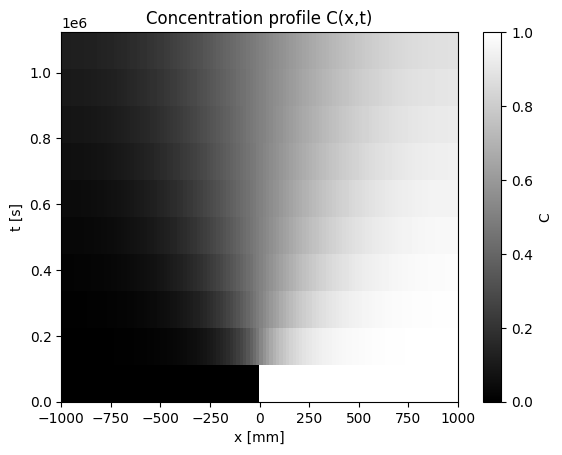

In [18]:
plt.imshow(C_matrix, aspect='auto', origin='lower', cmap='gray',
           extent=[x_min*1e3, x_max*1e3, 0, t_max])
plt.colorbar(label='C')
plt.xlabel('x [mm]')
plt.ylabel('t [s]')
plt.title('Concentration profile C(x,t)')
plt.show()

In [19]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

def animate_profile(C_matrix, x_min, x_max, dt, title='Concentration bar',
                    total_duration=15, n_frames=100):
    plt.close('all')
    t_steps, x_steps = C_matrix.shape
    x = np.linspace(x_min, x_max, x_steps)

    frames = np.linspace(0, t_steps - 1, min(n_frames, t_steps), dtype=int)
    interval_ms = int(total_duration * 1000 / len(frames))

    fig = plt.figure(figsize=(9, 5))
    ax_bar  = fig.add_axes([0.12, 0.78, 0.80, 0.14])
    ax_line = fig.add_axes([0.12, 0.14, 0.80, 0.52])

    img = ax_bar.imshow(C_matrix[[0]], cmap='gray', aspect='auto',
                        vmin=0, vmax=1, extent=[x_min, x_max, 0, 1])
    ax_bar.set_yticks([])
    ax_bar.set_xticks([])
    ttl = ax_bar.set_title(f'{title}, t = 0.00 hours')

    line, = ax_line.plot(x, C_matrix[0], lw=2)
    ax_line.set_xlim(x_min, x_max)
    ax_line.set_ylim(-0.02, 1.02)
    ax_line.set_xlabel('$x$ [mm]')
    ax_line.set_ylabel('$C$')
    ax_line.grid(alpha=0.3, lw=0.5)

    def update(i):
        n = frames[i]
        img.set_data(C_matrix[[n]])
        line.set_ydata(C_matrix[n])
        ttl.set_text(f'{title}, t = {n*dt/3600:.2f} hours')
        return img, line, ttl

    anim = FuncAnimation(fig, update, frames=len(frames),
                         interval=interval_ms, blit=False)
    plt.close(fig)                 # hindrer at det siste bildet vises i tillegg
    display(HTML(anim.to_jshtml()))

In [20]:
%matplotlib widget
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main()
animate_profile(C_matrix, x_min, x_max, dt,
                title='Self-diffusion, constant D');

In [21]:
def plot_profiles(C_matrix, x_min, x_max, dt, n_curves=2, title = ""):
    plt.close('all')          # lukker gamle widget-figurer

    t_steps, x_steps = C_matrix.shape
    x = np.linspace(x_min, x_max, x_steps)

    steps = np.linspace(0, t_steps - 1, n_curves, dtype=int)
    colors = plt.cm.viridis(np.linspace(0, 0.9, n_curves))

    plt.figure(figsize=(7, 4.5))
    for c, n in zip(colors, steps):
        plt.plot(x, C_matrix[n], color=c, lw=1.8, label=f'{n*dt/3600:.1f} h')
    plt.xlabel('$x$ [mm]')
    plt.ylabel('$C$')
    plt.xlim(x_min, x_max)
    plt.ylim(-0.02, 1.02)
    plt.grid(alpha=0.3, lw=0.5)
    plt.legend(frameon=False, title='$t$')
    plt.title(title)
    plt.tight_layout()
    plt.show()


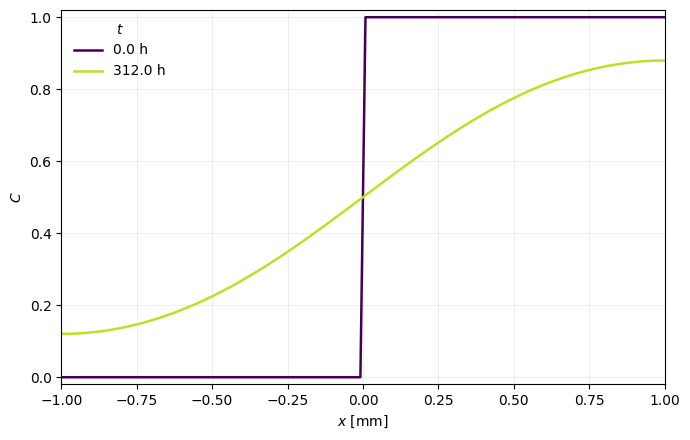

In [22]:
%matplotlib inline
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main()

plot_profiles(C_matrix, x_min, x_max, dt, n_curves=2)

## Part 1 (iv): Non-isothermal annealing (continuous heating 10 °C/h, 700–1000 °C)

### Why $D$ is computed inside the loop

In isothermal annealing $T$ is constant, so $D$ can be computed once before the loop. Here
$T$ rises steadily from 700 to 1000 °C, and since $D = D_0 e^{-Q/RT}$, $D$ changes all the way.
It must therefore be updated every time step, using the temperature at that moment:

```python
D = Diff_coeff(T_start + t * DT_dt, D0_Cu, Q_Cu)
```

The time step has to be moved inside the loop for the same reason: the stability criterion
$dt = \alpha\,dx^2/D$ depends on $D$. When the bar is cold, long time steps are allowed, and
as it heats up the steps must get shorter for the solution to remain stable.

Number of iterations: 637


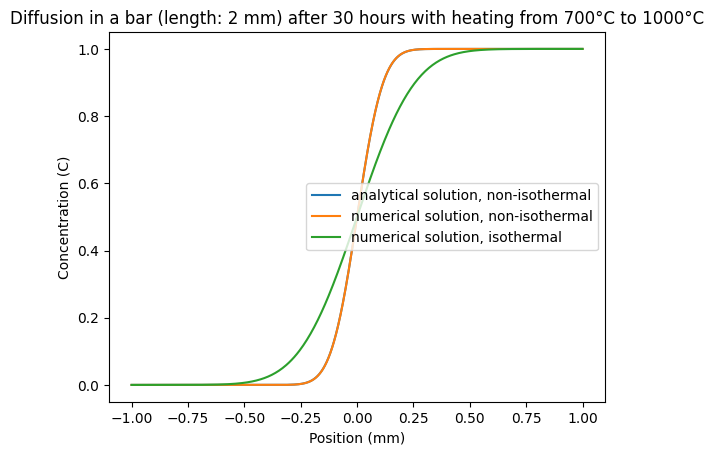

In [23]:
# Non-isothermal annealing

R = 8.314; D0_Cu = 31e-6; Q_Cu = 200.3
#------------------------------------------------------------------------

def central_diff(C, D, dx, D_list = None):
    if D_list is not None:
        # D midel between gridpoints:  D_{j+1/2} = (D_j + D_{j+1}) / 2
        D_face = 0.5 * (D_list[:-1] + D_list[1:])
        # Fick's 1st law on the faces:  J_{j+1/2} = -D_{j+1/2} * (C_{j+1} - C_j) / dx
        J = -D_face * (C[1:] - C[:-1]) / dx        # C[1:] = C_{j+1},  C[:-1] = C_j
    else:
        J = -D * (C[1:] - C[:-1]) / dx

    # dC_j/dt = -(J_{j+1/2} - J_{j-1/2}) / dx
    dCdt = np.zeros_like(C)
    dCdt[1:-1] = -(J[1:] - J[:-1]) / dx           # J[1:] = J_{j+1/2},  J[:-1] = J_{j-1/2}
    return dCdt, J

def iteration_annealing(C,T_start,T_end,dx,t_end,alpha=0.4):
    t = 0
    DT_dt = (T_end - T_start) / t_end
    C = np.array(C, dtype=float)
    history = [C.copy()]
    iterations = 0
    while t < t_end:
        D = Diff_coeff(T_start + t * DT_dt, D0_Cu, Q_Cu)
        dt = alpha * dx**2 / D
        dcdt, J = central_diff(C, D, dx)
        C = C + dt * dcdt
        history.append(C.copy())
        t += dt
        iterations += 1
    print("Number of iterations:", iterations)
    return history
    

def accumulated_Dt(T_start, T_end, t_end, n=10000):
    t = np.linspace(0, t_end, n)
    T_of_t = T_start + (T_end - T_start) * t / t_end
    return np.trapezoid(Diff_coeff(T_of_t, D0_Cu, Q_Cu), t)

def analytical_annealing(x, Dt, M=500):
    C = 0.5 + x / (2 * L)
    for m in range(1, M + 1):
        C += (1/(m*np.pi)) * np.sin(m*np.pi*x/L) * np.exp(-(m*np.pi/L)**2 * Dt)
    return C

#------------ Parameters -----------------
grid_points = 500 # number of points
t_end = 3600 * 30 # s (30 hours)
T = 1000 + 273 # K
L = 1e-3 # m, distance from the centre to the ends of the bar
T_start = 700 + 273 # K
T_final = 1000 + 273 # K

# C_grid
concentrations = np.zeros(grid_points)
concentrations[grid_points//2:] = 1.0

# positions
dx = 2*L / (grid_points - 1)   # same spacing as linspace gives
positions = np.linspace(-L,L,grid_points)
positions_fine = np.linspace(-L,L,1000)

D = Diff_coeff(T_final, D0_Cu, Q_Cu)
num_isothermal = iteration_1(concentrations,D,dx,t_end)
Dt = accumulated_Dt(T_start, T_final, t_end)   # replaces D*t when D is not constant
analy = analytical_annealing(positions_fine, Dt)
num = iteration_annealing(concentrations,T_start,T_final,dx,t_end)
num_isothermal = iteration_1(concentrations,D,dx,t_end)

plt.plot(positions_fine * 1e3,analy,label="analytical solution, non-isothermal")
plt.plot(positions * 1e3,num[-1],label="numerical solution, non-isothermal")   # num[-1] = last time step
plt.plot(positions * 1e3,num_isothermal[-1],label="numerical solution, isothermal")   # num_isothermal[-1] = last time step
plt.xlabel('Position (mm)')
plt.ylabel('Concentration (C)')
plt.title(f'Diffusion in a bar (length: {2*L*1e3:.0f} mm) after {t_end/3600:.0f} hours with heating from {T_start-273}°C to {T_final-273}°C')
plt.legend()
plt.show()

# Part 2: Interdiffusion in a Cu/Ni diffusion couple (Kirkendall effect)
## i) Calculate and plot interdiffusion coefficients
We are trying to plot fig. 2.21 in Porter and Easterling by linearising between the endpoints. The endpoints themselves are extracted from the figure.

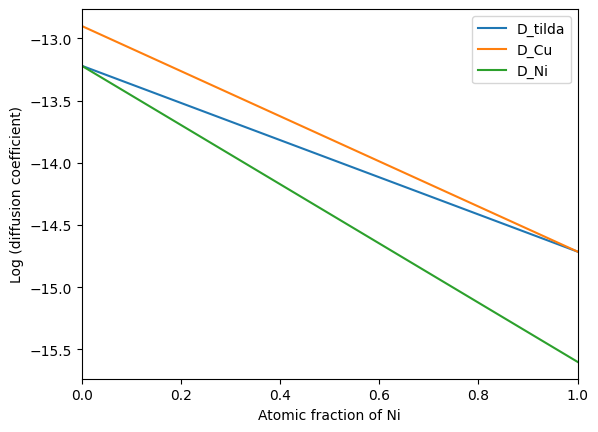

In [24]:
X_A=np.linspace(0,1,100)
values = pd.read_csv('D_tilda.csv', sep=';', header=None, decimal=',') # henter grafen til Vegard, men bruker bare endepunktene

D_Ni1= values.iloc[0, 1]
D_Ni2= -15.6
D_Cu2= values.iloc[-1, 1]
D_Cu1= -12.9

D_Cu_lin=D_Cu1-(D_Cu1-D_Cu2)*X_A
D_Ni_lin=D_Ni1-(D_Ni1-D_Ni2)*X_A

#Linear D̃
D_tilda_lin=(1-X_A)*D_Ni1+X_A*D_Cu2



plt.plot(X_A, D_tilda_lin, label='D_tilda')
plt.plot(X_A, D_Cu_lin, label='D_Cu')
plt.plot(X_A, D_Ni_lin, label='D_Ni')
plt.xlabel('Atomic fraction of Ni')
plt.ylabel('Log (diffusion coefficient)')
plt.margins(x=0)
plt.legend()
plt.show()

## Part 2 (ii)

Here, we need the r as a function of local composition

$$ \frac{\partial C}{\partial t} = \tilde{D} \frac{\partial ^2 C}{\partial x^2} + \frac{\partial C}{\partial x} \frac{\partial \tilde{D}}{\partial x} $$

The first part corresponds to the same as before. The second part can be implemented in two separate schemes multiplied together. 

$$\frac{C_j^{n+1}-C_j^n}{\Delta t} = \tilde D_j^n\,\frac{C_{j+1}^{n+1}-2C_j^{n+1}+C_{j-1}^{n+1}}{(\Delta x)^2} + \left(\frac{\tilde D_{j+1}^n-\tilde D_{j-1}^n}{2\Delta x}\right)\left(\frac{C_{j+1}^{n+1}-C_{j-1}^{n+1}}{2\Delta x}\right)$$

Solved:
$$-\left(\frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2} - \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}\right)C_{j-1}^{n+1} + \left(1+\frac{2\tilde D_j^n\,\Delta t}{(\Delta x)^2}\right)C_j^{n+1} - \left(\frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2} + \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}\right)C_{j+1}^{n+1} = C_j^n$$

Defining variables to simplify the expression

$$r_j = \frac{\tilde D_j^n\,\Delta t}{(\Delta x)^2}$$

$$s_j = \frac{\Delta t\,(\tilde D_{j+1}^n-\tilde D_{j-1}^n)}{4(\Delta x)^2}$$

Above, $\tilde D$ is evaluated at the old time level $n$, which makes the scheme semi-implicit. A fully implicit version would use $\tilde D_j^{n+1}=\tilde D(C_j^{n+1})$ instead, but since that depends on the unknown $C^{n+1}$, the system becomes non-linear. This is solved with a **Picard (fixed-point) iteration**: guess $C^{n+1,(0)}=C^n$, compute $r_j,s_j$ from that guess, solve the resulting linear system for a new iterate $C^{n+1,(k+1)}$, and repeat until the guess stops changing, i.e. until

$$
\left\|C^{n+1,(k+1)}-C^{n+1,(k)}\right\|_\infty < \mathrm{tol}
$$

At iteration $k$, evaluate $r_j^{(k)}$ and $s_j^{(k)}$ using $\mathbf C^{n+1,(k)}$, so that the matrix is $A^{(k)}=A(\mathbf C^{n+1,(k)})$. Then solve

$$
A(\mathbf C^{n+1,(k)})\mathbf C^{n+1,(k+1)}=\mathbf C^n.
$$

Thus,

$$
\mathbf C^{n+1,(k)}
\rightarrow
A(\mathbf C^{n+1,(k)})
\rightarrow
\mathbf C^{n+1,(k+1)}.
$$

Defining $G(\mathbf C^{n+1})$ as the solution $\mathbf X$ of

$$
A(\mathbf C^{n+1})\mathbf X=\mathbf C^n,
$$

the Picard iteration is

$$
\boxed{
\mathbf C^{n+1,(k+1)}
=
G\left(\mathbf C^{n+1,(k)}\right).
}
$$

If $G$ is a contraction, i.e. there exists $q<1$ such that

$$
\left\|
G(\mathbf C_1^{n+1})-G(\mathbf C_2^{n+1})
\right\|
\leq
q
\left\|
\mathbf C_1^{n+1}-\mathbf C_2^{n+1}
\right\|,
$$

then, by the Banach fixed-point theorem, the Picard iteration converges to the unique fixed point $\mathbf C^{n+1}$ satisfying

$$
\mathbf C^{n+1}=G(\mathbf C^{n+1}).
$$



In [25]:
# Importing the dataset from the csv file and sorting them


values = pd.read_csv('D_tilda.csv', sep=';', header=None, decimal=',')
composition = values[0].values
lg_D_tilda  = values[1].values


# Interpolating between the values


lg_D_tilda_spline = make_interp_spline(composition, lg_D_tilda, k=3)

In [26]:
# Taking in one step of concentrations and returning the effective diffusion coefficient D_tilda for each point in space.
def D_tilda(lg_D, C1_vector):
    return D1 * (1 - C1_vector) + D2 * C1_vector   # vektorisert

def D_tilda2(C1_vector):
    return D * (1 - C1_vector) + D * C1_vector   # vektorisert

# Defining the r for each D

def D_tilda_spline_vector(C1_vector):
    C1_vector = np.clip(C1_vector, composition.min(), composition.max())   # splinen skal aldri ekstrapolere
    lg_D_tilda_vector = lg_D_tilda_spline(C1_vector)
    return 10**lg_D_tilda_vector * 10**6

def r_vector(D_tilda_vector, dt, dx):
    return D_tilda_vector * dt / dx**2   # vektorisert, ingen loop nødvendig

# Defining the s for each D

def s_vector(D_tilda_vector, dt, dx):
    s = np.zeros(len(D_tilda_vector))
    s[1:-1] = (D_tilda_vector[2:] - D_tilda_vector[:-2]) * dt / (4 * dx**2)
    return s



With the new quantities defined, the same implicit scheme can be used

In [27]:
def main2():
    for step in range(0, t_steps-1):
        D_tilda_vector = D_tilda_spline_vector(C_matrix[step])
        r = r_vector(D_tilda_vector, dt, dx)
        s = s_vector(D_tilda_vector, dt, dx)
        C_matrix[step+1, :] = implicit_system_one_step(C_matrix, r, step, s, Picard=True, dt=dt, dx=dx)

    return C_matrix


In [28]:
%matplotlib widget
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main2()
animate_profile(C_matrix, x_min, x_max, dt,
                title='Interdiffusion, concentration-dependent D');

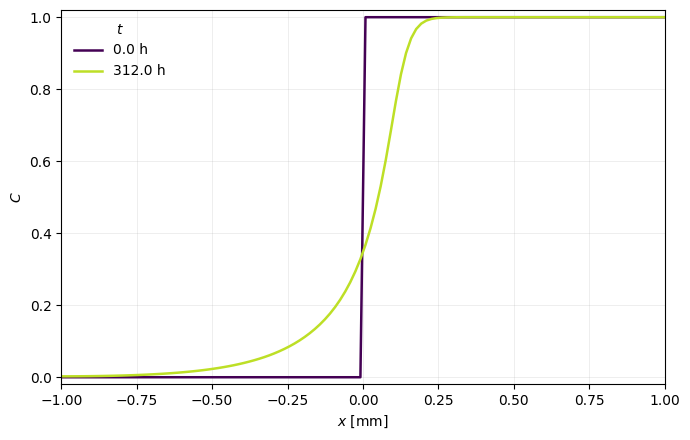

In [29]:
%matplotlib inline
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main2()
plot_profiles(C_matrix, x_min, x_max, dt, n_curves=2)

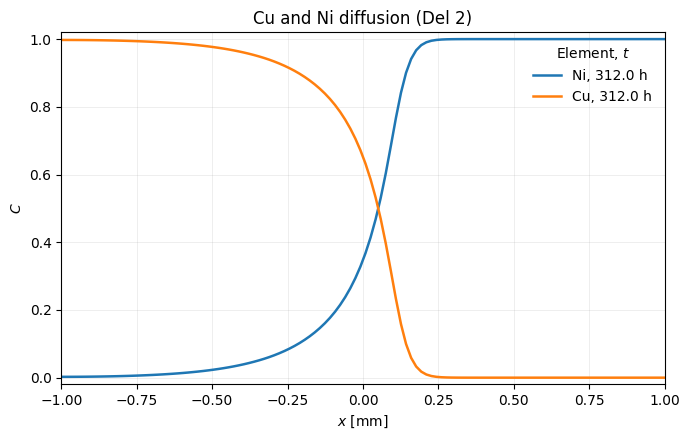

In [30]:
%matplotlib inline
plt.close('all')

C_matrix, dx, dt, r, x = setup()
C_matrix = main2()

plt.figure(figsize=(7, 4.5))
plt.plot(x, C_matrix[-1], color='#1f77b4', lw=1.8, label=f'Ni, {(t_steps-1)*dt/3600:.1f} h')
plt.plot(x, 1 - C_matrix[-1], color='#ff7f0e', lw=1.8, label=f'Cu, {(t_steps-1)*dt/3600:.1f} h')
plt.xlabel('$x$ [mm]')
plt.ylabel('$C$')
plt.xlim(x_min, x_max)
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.3, lw=0.5)
plt.legend(frameon=False, title='Element, $t$')
plt.title('Cu and Ni diffusion (Del 2)')
plt.tight_layout()
plt.show()

In [31]:
print("C spenn:", C_matrix.min(), C_matrix.max())
print("masse start:", C_matrix[0].sum(), " slutt:", C_matrix[-1].sum())

C spenn: 0.0 1.0
masse start: 60.0  slutt: 60.04806300149983


In [32]:
def mse_between_tsteps(configs_del1, configs_del2, x_steps=x_steps, x_min=x_min, x_max=x_max, D=D):
    """
    configs_del1, configs_del2: lister av (t_max, t_steps)-par som testes for hhv Del 1 og Del 2.
    Returnerer én tabell med MSE mellom sluttprofilene for påfølgende konfigurasjoner i hver liste.
    """
    def run(configs, del2):
        final_profiles = []
        for t_max_i, ts in configs:
            Cm, dx_, dt_, r_, x_ = setup(x_min=x_min, x_max=x_max, x_steps=x_steps, t_max=t_max_i, t_steps=ts, D=D)
            for step in range(ts - 1):
                if del2:
                    D_tilda_vector = D_tilda_spline_vector(Cm[step])
                    r_step = r_vector(D_tilda_vector, dt_, dx_)
                    s_step = s_vector(D_tilda_vector, dt_, dx_)
                    Cm[step+1, :] = implicit_system_one_step(Cm, r_step, step, s_step)
                else:
                    Cm[step+1, :] = implicit_system_one_step(Cm, r_, step)
            final_profiles.append(Cm[-1, :])
        return [np.mean((final_profiles[i+1] - final_profiles[i])**2) for i in range(len(final_profiles) - 1)]

    mse_del1 = run(configs_del1, del2=False)
    mse_del2 = run(configs_del2, del2=True)

    rows = []
    for i, mse in enumerate(mse_del1):
        rows.append({'del': 1,
                      't_max_from': configs_del1[i][0], 't_steps_from': configs_del1[i][1],
                      't_max_to': configs_del1[i+1][0], 't_steps_to': configs_del1[i+1][1],
                      'mse': mse})
    for i, mse in enumerate(mse_del2):
        rows.append({'del': 2,
                      't_max_from': configs_del2[i][0], 't_steps_from': configs_del2[i][1],
                      't_max_to': configs_del2[i+1][0], 't_steps_to': configs_del2[i+1][1],
                      'mse': mse})

    return pd.DataFrame(rows)


mse_between_tsteps([(t_max, 25), (t_max, 1000)], [(t_max, 25), (t_max, 1000)])

,del,t_max_from,t_steps_from,t_max_to,t_steps_to,mse
0,1,1123200,25,1123200,1000,2.102493e-17
1,2,1123200,25,1123200,1000,2.853188e-01


In [33]:
def run_variant(picard, dirichlet, x_steps=x_steps, x_min=x_min, x_max=x_max, t_max=t_max, t_steps=t_steps, D=D):
    Cm, dx_, dt_, r_, x_ = setup(x_min=x_min, x_max=x_max, x_steps=x_steps, t_max=t_max, t_steps=t_steps, D=D)
    for step in range(t_steps - 1):
        D_tilda_vector = D_tilda_spline_vector(Cm[step])
        r = r_vector(D_tilda_vector, dt_, dx_)
        s = s_vector(D_tilda_vector, dt_, dx_)
        Cm[step+1, :] = implicit_system_one_step(Cm, r, step, s, Dirichlet=dirichlet, Picard=picard, dt=dt_, dx=dx_)
    return Cm[-1, :], x_, t_steps


baseline,      x_, t_steps_baseline  = run_variant(picard=False, dirichlet=False)
picard_run,    x_, t_steps_picard    = run_variant(picard=True,  dirichlet=False)
dirichlet_run, x_, t_steps_dirichlet = run_variant(picard=False, dirichlet=True)

mse_picard    = np.mean((picard_run - baseline)**2)
mse_dirichlet = np.mean((dirichlet_run - baseline)**2)

print("MSE Picard vs semi-implisitt:", mse_picard, "| t_steps brukt:", t_steps_picard, "| t_max:", t_max0, "h")
print("MSE Dirichlet vs Neumann:    ", mse_dirichlet, "| t_steps brukt:", t_steps_dirichlet, "| t_max:", t_max0, "h")

# Fasit: en høyoppløst Picard-referanseløsning (1000 tidssteg), brukt som "sannhet".
# Her sammenlignes semi-implisitt og Picard hver for seg mot fasiten, ikke mot hverandre.
t_steps_ref = 1000
reference, x_ref, t_steps_ref_used = run_variant(picard=True, dirichlet=False, t_steps=t_steps_ref)

mse_baseline_vs_ref = np.mean((baseline - reference)**2)
mse_picard_vs_ref   = np.mean((picard_run - reference)**2)

print(f"MSE semi-implisitt vs fasit ({t_steps_ref_used} steg):", mse_baseline_vs_ref)
print(f"MSE Picard vs fasit ({t_steps_ref_used} steg):        ", mse_picard_vs_ref)

MSE Picard vs semi-implisitt: 0.13023016266634296 | t_steps brukt: 10 | t_max: 312 h
MSE Dirichlet vs Neumann:     5.084325594615153e-06 | t_steps brukt: 10 | t_max: 312 h
MSE semi-implisitt vs fasit (1000 steg): 0.12880520998618758
MSE Picard vs fasit (1000 steg):         8.820882671094036e-06


# Extra: Monte Carlo simulation of vacancy diffusion

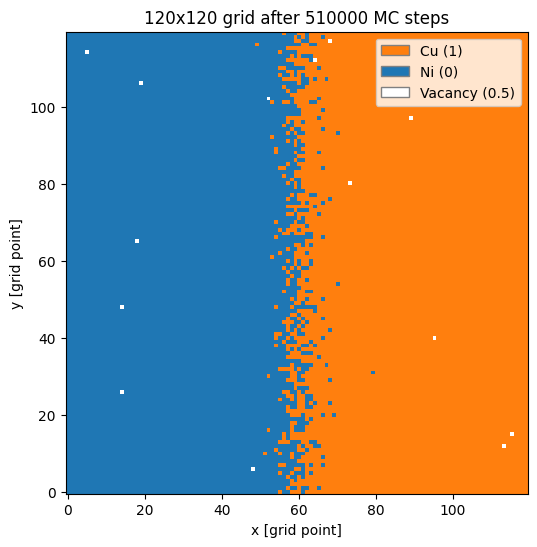

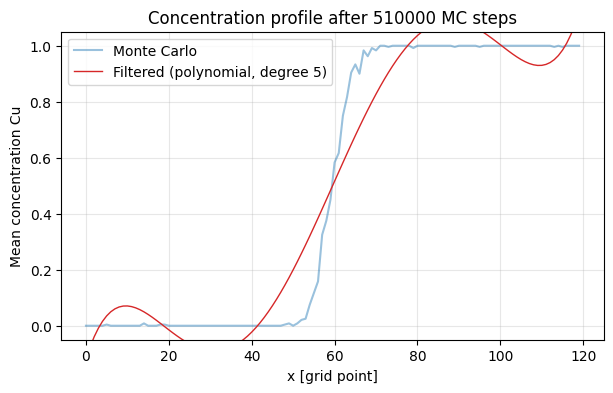

In [34]:
# Monte Carlo approach to find Fick's first law through vacancies

#----------- Parameters -----------------
x_grid = 120
y_grid = 120
MC_steps = 0.51e6
vacancy_volume = 0.1 # percent

MC_steps = int(MC_steps)
vacancy_volume = vacancy_volume/100

Grid = np.zeros((x_grid, y_grid))
Grid[len(Grid)//2:,:] = 1
n_vacancies = int(vacancy_volume * x_grid * y_grid)
for i in range(n_vacancies):
    x = np.random.randint(0, x_grid)
    y = np.random.randint(0, y_grid)
    Grid[x, y] = 0.5

# ------------------ Monte Carlo part -----------------------------
def Monte_carlo_diff(Grid, MC):
    vacancies = np.argwhere(Grid == 0.5)   # array with [x, y] for each vacancy
    # pre-generate some values for faster code
    choice = np.random.randint(0, len(vacancies), MC)
    dxs = np.random.choice([-1, 1], MC)
    dys = np.random.choice([-1, 1], MC)
    for i in range(MC):
        inx = choice[i]
        x, y = vacancies[inx]
        dx = dxs[i]
        dy = dys[i]
        if x + dx < 0 or x + dx >= x_grid:
            dx = 0
        if y + dy < 0 or y + dy >= y_grid:
            dy = 0
        neighbour = Grid[x + dx, y + dy]
        if neighbour != 0.5:                 # the neighbour is an atom (Cu or Ni), not another vacancy
            Grid[x, y] = neighbour           # the atom moves into where the vacancy was
            Grid[x + dx, y + dy] = 0.5       # the vacancy ends up where the atom was
            vacancies[inx] = [x + dx, y + dy]  # updates the position of the vacancy
    return Grid

Grid = Monte_carlo_diff(Grid, MC_steps)

# ---------------------- Plotting ----------------------
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

colors = ListedColormap(['tab:blue', 'white', 'tab:orange'])
norm = BoundaryNorm([-0.25, 0.25, 0.75, 1.25], colors.N)
plt.figure(figsize=(6, 6))
plt.imshow(Grid.T, cmap=colors, norm=norm, origin='lower', interpolation='nearest')
plt.xlabel('x [grid point]')
plt.ylabel('y [grid point]')
plt.title(f'{x_grid}x{y_grid} grid after {MC_steps} MC steps')
plt.legend(handles=[Patch(facecolor='tab:orange', edgecolor='grey', label='Cu (1)'),Patch(facecolor='tab:blue', edgecolor='grey', label='Ni (0)'),Patch(facecolor='white', edgecolor='grey', label='Vacancy (0.5)')],loc='upper right')
plt.show()

#------------- Mean concentration per x position --------
# the mean over all y for each x, i.e. np.mean(Grid[i,:]) for i = 0..x_grid-1
mean_profile = Grid.mean(axis=1)

# Filtering: least-squares fit of one polynomial over the whole profile.
degree = 5
mean_smoothed = np.polyval(np.polyfit(np.arange(x_grid), mean_profile, degree), np.arange(x_grid))

plt.figure(figsize=(7, 4))
plt.plot(np.arange(x_grid), mean_profile, '-', ms=3, alpha=0.45, label='Monte Carlo')
plt.plot(np.arange(x_grid), mean_smoothed, '-', lw=1, color='tab:red', label=f'Filtered (polynomial, degree {degree})')
plt.xlabel('x [grid point]')
plt.ylabel('Mean concentration Cu')
plt.title(f'Concentration profile after {MC_steps} MC steps')
plt.ylim(-0.05, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.show()

explicit: 10000 steps, dt = 112 s, 232 ms, MSE = 4.74e-10
implicit steps sweep:
     50 steps, dt =  22464 s,     10 ms, MSE = 3.17e-04
    100 steps, dt =  11232 s,     19 ms, MSE = 5.45e-06
    150 steps, dt =   7488 s,     28 ms, MSE = 1.49e-07
    200 steps, dt =   5616 s,     39 ms, MSE = 8.70e-08
    250 steps, dt =   4493 s,     48 ms, MSE = 1.87e-07
    300 steps, dt =   3744 s,     58 ms, MSE = 2.21e-07
    400 steps, dt =   2808 s,     75 ms, MSE = 2.05e-07
    600 steps, dt =   1872 s,    111 ms, MSE = 1.29e-07
   1000 steps, dt =   1123 s,    195 ms, MSE = 5.50e-08
-> equal runtime (~232 ms): implicit needs ~1000 steps vs 10000 explicit; explicit MSE is 116x lower


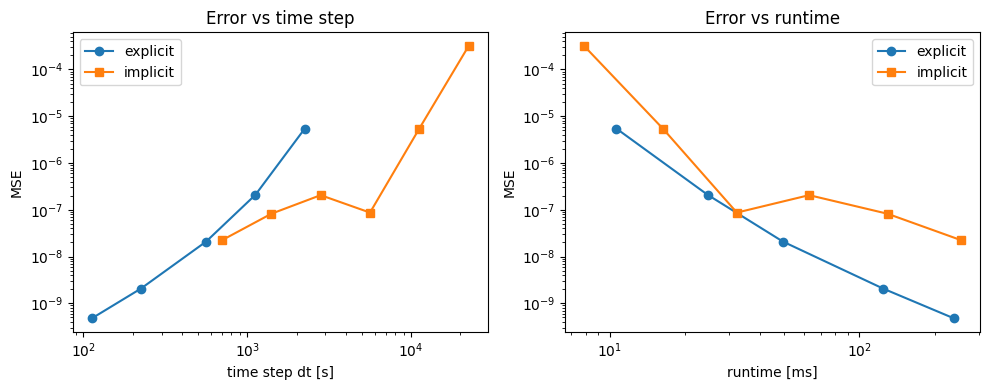

In [40]:
import time

def explicit_part2(C0, dx, dt, n):
    C = C0.copy()
    for _ in range(n):
        Dv = D_tilda_spline_vector(C)
        r, s = r_vector(Dv, dt, dx), s_vector(Dv, dt, dx)
        Cn = C.copy()
        Cn[1:-1] = C[1:-1] + r[1:-1]*(C[2:] - 2*C[1:-1] + C[:-2]) + s[1:-1]*(C[2:] - C[:-2])
        Cn[0]  = C[0]  + 2*r[0]*(C[1] - C[0])
        Cn[-1] = C[-1] + 2*r[-1]*(C[-2] - C[-1])
        C = Cn
    return C

def implicit_part2(n, picard=False):
    C_m, dx_, dt_, r_, x_ = setup(x_steps=x_steps, t_max=t_max, t_steps=n + 1)
    t0 = time.perf_counter()
    for step in range(n):
        Dv = D_tilda_spline_vector(C_m[step])
        C_m[step+1] = implicit_system_one_step(C_m, r_vector(Dv, dt_, dx_), step, s_vector(Dv, dt_, dx_),
                                               Picard=picard, dt=dt_, dx=dx_)
    return C_m[-1], time.perf_counter() - t0

C_m, dx_c, dt_c, r_c, x_c = setup(x_steps=x_steps, t_max=t_max, t_steps=2)
C0 = C_m[0]
n_exp = 10000
ref = explicit_part2(C0, dx_c, t_max / (16*n_exp), 16*n_exp)       # fine explicit reference, same grid

# explicit (best of 3 timings)
time_exp = np.inf
for _ in range(3):
    t0 = time.perf_counter()
    C_exp = explicit_part2(C0, dx_c, t_max / n_exp, n_exp)
    time_exp = min(time_exp, time.perf_counter() - t0)
mse_exp = np.mean((C_exp - ref)**2)
print(f"explicit: {n_exp} steps, dt = {t_max/n_exp:.0f} s, {time_exp*1e3:.0f} ms, MSE = {mse_exp:.2e}")

# implicit: sweep the number of steps; the row with runtime closest to explicit is the equal-time comparison
print("implicit steps sweep:")
best = None
for n in (50, 100, 150, 200, 250, 300, 400, 600, 1000):
    C_imp, time_imp = implicit_part2(n)
    mse_imp = np.mean((C_imp - ref)**2)
    print(f"  {n:5d} steps, dt = {t_max/n:6.0f} s, {time_imp*1e3:6.0f} ms, MSE = {mse_imp:.2e}")
    if best is None or abs(time_imp - time_exp) < abs(best[1] - time_exp):
        best = (n, time_imp, mse_imp)
n_match, time_imp, mse_imp = best
print(f"-> equal runtime (~{time_exp*1e3:.0f} ms): implicit needs ~{n_match} steps vs {n_exp} explicit; "
      f"explicit MSE is {mse_imp/mse_exp:.0f}x lower")


# ---------------- convergence plot ----------------


dt_exp, time_e, mse_e = [], [], []
for n in [500, 1000, 2000, 5000, 10000]:
    t0 = time.perf_counter()
    C = explicit_part2(C0, dx_c, t_max / n, n)
    time_e.append(time.perf_counter() - t0)
    dt_exp.append(t_max / n)
    mse_e.append(np.mean((C - ref)**2))

dt_imp, time_i, mse_i = [], [], []
for n in [50, 100, 200, 400, 800, 1600]:
    C, t = implicit_part2(n)
    time_i.append(t)
    dt_imp.append(t_max / n)
    mse_i.append(np.mean((C - ref)**2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.loglog(dt_exp, mse_e, 'o-', label='explicit')
ax1.loglog(dt_imp, mse_i, 's-', label='implicit')
ax1.set_xlabel('time step dt [s]')
ax1.set_ylabel('MSE')
ax1.set_title('Error vs time step')
ax1.legend()

ax2.loglog(np.array(time_e) * 1e3, mse_e, 'o-', label='explicit')
ax2.loglog(np.array(time_i) * 1e3, mse_i, 's-', label='implicit')
ax2.set_xlabel('runtime [ms]')
ax2.set_ylabel('MSE')
ax2.set_title('Error vs runtime')
ax2.legend()

plt.tight_layout()
plt.show()